# Week 2 — Exploratory Data Analysis

## Objectives

- Load and combine the six monthly CRMLS sold-property CSV files.
- Check file coverage, dimensions, column names, and missing values.
- Restrict the analysis to residential single-family properties.
- Explore the distributions of the principal numerical variables.
- Identify unusual values that should be handled during preprocessing.

## Required input

The notebook expects the raw monthly CSV files inside a folder named:

`data/`

It works when the notebook is stored either in the project root or inside a `notebooks` folder.

## Main variables

- `ClosePrice`
- `LivingArea`
- `Bedrooms`
- `Bathrooms`
- `LotSize`

This notebook displays its results inside the notebook and does not create additional output files.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


## 1. Define the project folders and locate the raw CSV files

The path logic below supports both of these arrangements:

```text
project/
├── data/
└── 01_exploration.ipynb
```

and:

```text
project/
├── data/
└── notebooks/
    └── 01_exploration.ipynb
```


In [2]:
working_dir = Path.cwd()

project_root = (
    working_dir.parent
    if working_dir.name.lower() == "notebooks"
    else working_dir
)

data_dir = project_root / "data"
csv_files = sorted(data_dir.glob("*.csv"))

if not data_dir.exists():
    raise FileNotFoundError(
        "The data folder was not found. Create a folder named 'data' "
        "in the project root and place the monthly CSV files inside it."
    )

if not csv_files:
    raise FileNotFoundError(
        "No CSV files were found inside the data folder."
    )

print("Number of CSV files found:", len(csv_files))

if len(csv_files) != 6:
    print(
        "Warning: This project originally expected six monthly CSV files, "
        f"but {len(csv_files)} file(s) were found."
    )

pd.DataFrame({
    "Source_File": [file.name for file in csv_files],
    "File_Size_MB": [
        round(file.stat().st_size / 1024**2, 2)
        for file in csv_files
    ],
})


Number of CSV files found: 6


,Source_File,File_Size_MB
0,CRMLSSold202512.csv,10.89
1,CRMLSSold202601.csv,8.74
2,CRMLSSold202602.csv,9.60
3,CRMLSSold202603.csv,11.94
4,CRMLSSold202604.csv,12.36
5,CRMLSSold202605.csv,12.30


## 2. Load and combine the monthly datasets

A `SourceFile` column is added before combining the files so each observation can be traced back to its original monthly file.


In [3]:
monthly_frames = []
file_summary = []

for file in csv_files:
    monthly_df = pd.read_csv(file, low_memory=False)
    monthly_df.columns = monthly_df.columns.str.strip()
    monthly_df["SourceFile"] = file.name

    monthly_frames.append(monthly_df)

    file_summary.append({
        "Source_File": file.name,
        "Rows": monthly_df.shape[0],
        "Columns": monthly_df.shape[1],
    })

df = pd.concat(monthly_frames, ignore_index=True, sort=False)

print("Combined dataset shape:", df.shape)
pd.DataFrame(file_summary)


Combined dataset shape: (124404, 79)


,Source_File,Rows,Columns
0,CRMLSSold202512.csv,20538,79
1,CRMLSSold202601.csv,16487,79
2,CRMLSSold202602.csv,18124,79
3,CRMLSSold202603.csv,22583,79
4,CRMLSSold202604.csv,23412,79
5,CRMLSSold202605.csv,23260,79


## 3. Standardize column names and validate the required variables

The raw MLS names are renamed to the shorter names used throughout the project.


In [4]:
df.columns = df.columns.str.strip()

rename_map = {
    "BedroomsTotal": "Bedrooms",
    "BathroomsTotalInteger": "Bathrooms",
    "LotSizeSquareFeet": "LotSize",
}

df = df.rename(
    columns={
        old_name: new_name
        for old_name, new_name in rename_map.items()
        if old_name in df.columns and new_name not in df.columns
    }
)

required_columns = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "PropertyType",
    "PropertySubType",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

duplicate_columns = df.columns[df.columns.duplicated()].tolist()

if duplicate_columns:
    raise ValueError(
        f"Duplicate column names were found: {duplicate_columns[:10]}"
    )

print("All required columns are available.")
print("Duplicate column count:", len(duplicate_columns))


All required columns are available.
Duplicate column count: 0


## 4. Review property categories before filtering

This check confirms how the residential and single-family labels appear in the raw data.


In [5]:
print("Most common PropertyType values:")
display(
    df["PropertyType"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .head(10)
    .to_frame("Count")
)

print("\nMost common PropertySubType values:")
display(
    df["PropertySubType"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .head(10)
    .to_frame("Count")
)


Most common PropertyType values:


,Count
PropertyType,
Residential,82643
ResidentialLease,29673
Land,4012
ResidentialIncome,3381
ManufacturedInPark,3186
CommercialSale,805
CommercialLease,638
BusinessOpportunity,66



Most common PropertySubType values:


,Count
PropertySubType,
SingleFamilyResidence,75250
Condominium,21716
<NA>,9185
Townhouse,7207
Apartment,3431
Duplex,2505
ManufacturedOnLand,1227
Triplex,854
Quadruplex,786


## 5. Filter to residential single-family properties

The project focuses on observations satisfying both conditions:

- `PropertyType = Residential`
- `PropertySubType = SingleFamilyResidence`


In [6]:
property_type = (
    df["PropertyType"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

property_subtype = (
    df["PropertySubType"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

single_family_mask = (
    property_type.eq("residential")
    & property_subtype.eq("singlefamilyresidence")
)

df_filtered = df.loc[single_family_mask].copy()

filter_summary = pd.DataFrame({
    "Dataset": [
        "Combined raw data",
        "Residential single-family data",
    ],
    "Rows": [
        len(df),
        len(df_filtered),
    ],
})

filter_summary["Share_of_Raw_Data"] = (
    filter_summary["Rows"] / len(df)
)

filter_summary


,Dataset,Rows,Share_of_Raw_Data
0,Combined raw data,124404,1.00
1,Residential single-family data,61727,0.50


## 6. Prepare the numerical EDA variables

Each selected column is converted to numeric form. Invalid text values become missing values rather than causing the notebook to fail.


In [7]:
eda_columns = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
]

eda_df = df_filtered[eda_columns].copy()

for column in eda_columns:
    eda_df[column] = pd.to_numeric(
        eda_df[column],
        errors="coerce",
    )

print("EDA dataset shape:", eda_df.shape)
eda_df.head()


EDA dataset shape: (61727, 5)


,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
0,"1,998,000.00","2,045.00",4.00,2.00,"10,080.00"
2,"2,214,421.00","3,050.00",4.00,4.00,"34,745.00"
3,"1,200,000.00","1,594.00",4.00,2.00,"6,600.00"
7,"3,100,000.00","2,700.00",5.00,3.00,"8,262.00"
9,"2,900,000.00","2,948.00",5.00,4.00,"9,222.00"


## 7. Examine missing values

Missingness is evaluated separately for each variable. The notebook does not drop all incomplete observations at once because doing so would unnecessarily remove valid values from other analyses.


In [8]:
missing_summary = pd.DataFrame({
    "Missing_Count": eda_df.isna().sum(),
    "Missing_Percent": eda_df.isna().mean() * 100,
})

missing_summary.index.name = "Variable"
missing_summary.sort_values(
    "Missing_Percent",
    ascending=False,
)


,Missing_Count,Missing_Percent
Variable,,
LotSize,1081,1.75
LivingArea,30,0.05
Bathrooms,1,0.00
ClosePrice,0,0.00
Bedrooms,0,0.00


## 8. Review descriptive statistics

The 1st and 99th percentiles are included to reveal skewness and unusually large or small observations.


In [9]:
descriptive_statistics = (
    eda_df
    .describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    )
    .T
)

descriptive_statistics.index.name = "Variable"
descriptive_statistics


,count,mean,std,min,1%,25%,50%,75%,99%,max
Variable,,,,,,,,,,
ClosePrice,"61,727.00","1,340,106.06","7,307,628.93",1.75,"230,000.00","620,000.00","890,000.00","1,425,000.00","6,500,000.00","796,000,000.00"
LivingArea,"61,697.00","2,055.55","1,037.24",0.00,738.00,"1,386.00","1,826.00","2,455.00","5,698.12","23,314.00"
Bedrooms,"61,727.00",3.50,0.97,0.00,2.00,3.00,3.00,4.00,6.00,22.00
Bathrooms,"61,726.00",2.64,1.14,0.00,1.00,2.00,2.00,3.00,6.00,22.00
LotSize,"60,646.00","385,948.90","18,434,009.61",0.00,"1,722.00","5,663.00","7,263.50","10,454.00","307,032.75","1,897,473,600.00"


## 9. Flag unusual values for later preprocessing

These checks do not delete observations. They identify values that may require investigation in the preprocessing notebook.


In [10]:
quality_checks = pd.DataFrame({
    "Check": [
        "ClosePrice is missing",
        "ClosePrice is nonpositive",
        "ClosePrice is below $10,000",
        "LivingArea is missing",
        "LivingArea is nonpositive",
        "Bedrooms is negative",
        "Bathrooms is negative",
        "LotSize is negative",
    ],
    "Affected_Rows": [
        eda_df["ClosePrice"].isna().sum(),
        eda_df["ClosePrice"].le(0).sum(),
        eda_df["ClosePrice"].lt(10_000).sum(),
        eda_df["LivingArea"].isna().sum(),
        eda_df["LivingArea"].le(0).sum(),
        eda_df["Bedrooms"].lt(0).sum(),
        eda_df["Bathrooms"].lt(0).sum(),
        eda_df["LotSize"].lt(0).sum(),
    ],
})

quality_checks["Percent_of_Filtered_Data"] = (
    quality_checks["Affected_Rows"]
    / len(eda_df)
    * 100
)

quality_checks


,Check,Affected_Rows,Percent_of_Filtered_Data
0,ClosePrice is missing,0,0.00
1,ClosePrice is nonpositive,0,0.00
2,"ClosePrice is below $10,000",4,0.01
3,LivingArea is missing,30,0.05
4,LivingArea is nonpositive,19,0.03
5,Bedrooms is negative,0,0.00
6,Bathrooms is negative,0,0.00
7,LotSize is negative,0,0.00


## 10. Examine correlations

The correlation table provides an initial view of linear relationships. It is exploratory only and does not establish causation.


In [11]:
correlation_matrix = eda_df.corr(
    method="pearson",
    min_periods=2,
)

correlation_matrix


Variable,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
Variable,,,,,
ClosePrice,1.00,0.12,0.06,0.11,-0.00
LivingArea,0.12,1.00,0.66,0.85,0.01
Bedrooms,0.06,0.66,1.00,0.66,0.01
Bathrooms,0.11,0.85,0.66,1.00,0.00
LotSize,-0.00,0.01,0.01,0.00,1.00


## 11. Plot the numerical distributions

To keep extreme outliers from compressing the main part of each histogram, the displayed horizontal range is capped at the 99th percentile. This changes only the visualization, not the underlying data.


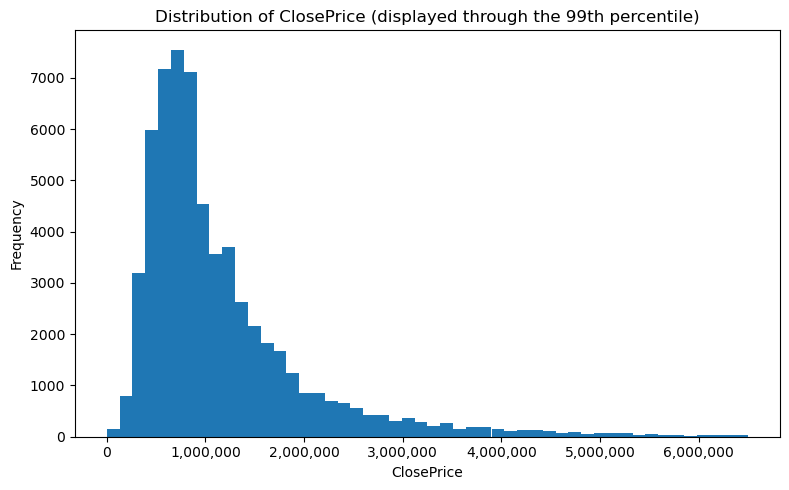

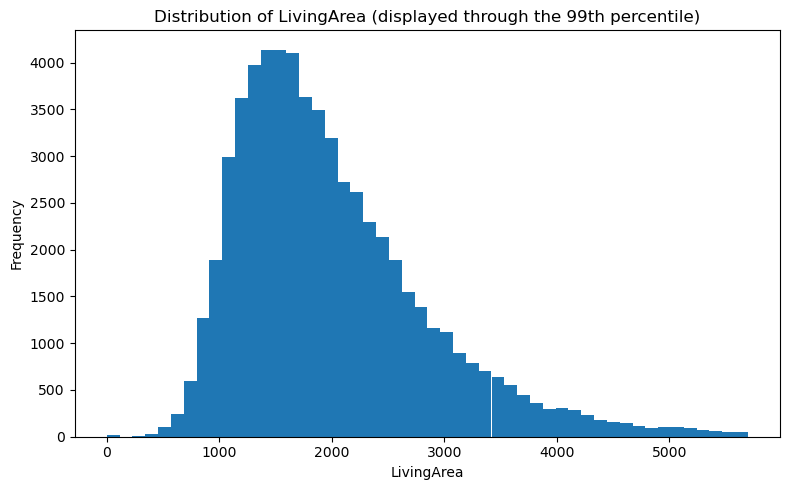

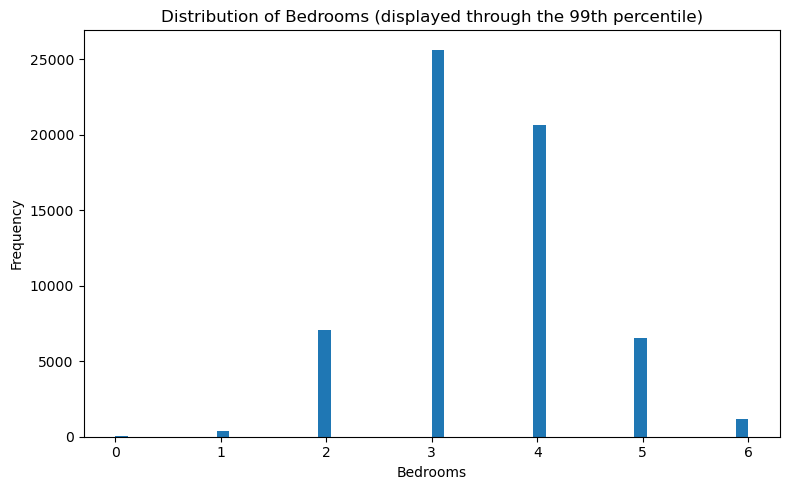

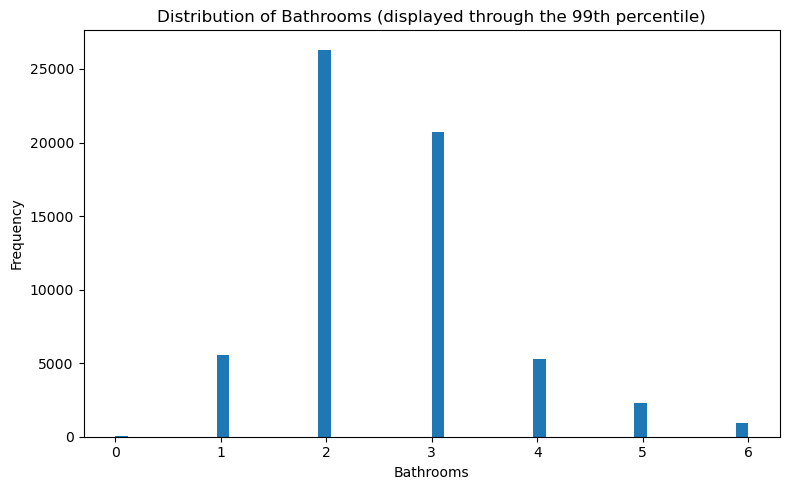

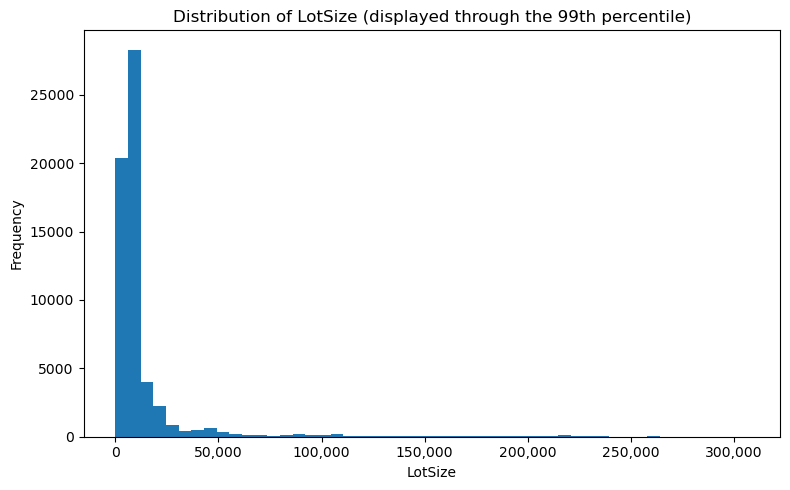

In [12]:
def plot_distribution(data, column, bins=50):
    values = data[column].dropna()

    if values.empty:
        print(f"No valid values are available for {column}.")
        return

    upper_limit = values.quantile(0.99)
    displayed_values = values[values <= upper_limit]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(displayed_values, bins=bins)

    ax.set_title(
        f"Distribution of {column} "
        "(displayed through the 99th percentile)"
    )
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

    if column in {"ClosePrice", "LotSize"}:
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, _: f"{value:,.0f}"
            )
        )

    fig.tight_layout()
    plt.show()


for column in eda_columns:
    plot_distribution(eda_df, column)


## 12. Plot closing price against living area

Both axes are capped at their 99th percentiles for display. The original observations remain unchanged.


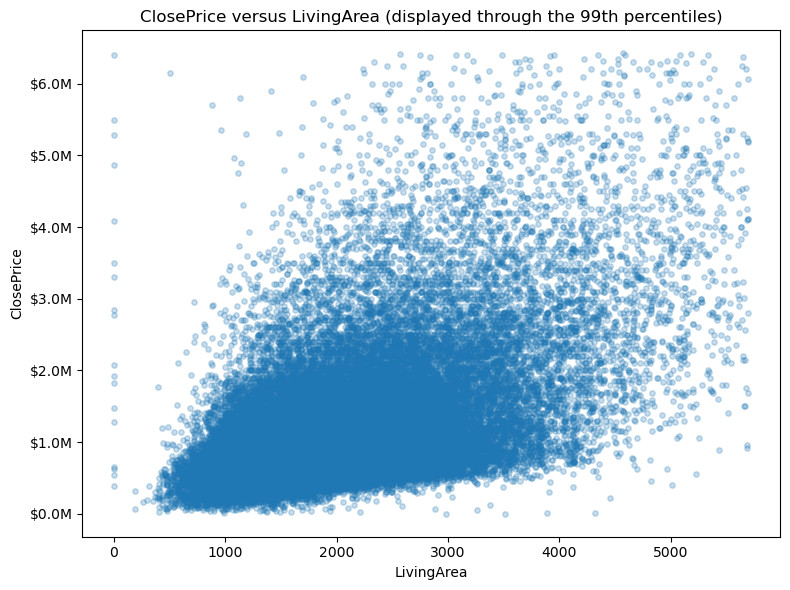

In [13]:
scatter_data = (
    eda_df[["LivingArea", "ClosePrice"]]
    .dropna()
)

living_area_limit = scatter_data["LivingArea"].quantile(0.99)
close_price_limit = scatter_data["ClosePrice"].quantile(0.99)

scatter_display = scatter_data[
    scatter_data["LivingArea"].le(living_area_limit)
    & scatter_data["ClosePrice"].le(close_price_limit)
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    scatter_display["LivingArea"],
    scatter_display["ClosePrice"],
    alpha=0.25,
    s=15,
)

ax.set_title(
    "ClosePrice versus LivingArea "
    "(displayed through the 99th percentiles)"
)
ax.set_xlabel("LivingArea")
ax.set_ylabel("ClosePrice")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"${value / 1_000_000:,.1f}M"
    )
)

fig.tight_layout()
plt.show()


## 13. Automated EDA summary


In [14]:
complete_case_count = eda_df.dropna().shape[0]

price_area_correlation = correlation_matrix.loc[
    "ClosePrice",
    "LivingArea",
]

print("Exploratory Data Summary")
print("------------------------")
print(f"Raw observations: {len(df):,}")
print(
    "Residential single-family observations: "
    f"{len(df_filtered):,}"
)
print(
    "Complete observations across all five EDA variables: "
    f"{complete_case_count:,}"
)
print(
    "Median closing price: "
    f"${eda_df['ClosePrice'].median():,.0f}"
)
print(
    "Median living area: "
    f"{eda_df['LivingArea'].median():,.0f}"
)
print(
    "Correlation between ClosePrice and LivingArea: "
    f"{price_area_correlation:.4f}"
)


Exploratory Data Summary
------------------------
Raw observations: 124,404
Residential single-family observations: 61,727
Complete observations across all five EDA variables: 60,616
Median closing price: $890,000
Median living area: 1,826
Correlation between ClosePrice and LivingArea: 0.1182


## Conclusion

This notebook combines the monthly CRMLS files and establishes the initial analytical sample of residential single-family properties.

The descriptive tables, missing-value checks, unusual-value flags, and visualizations should guide the decisions made in `02_preprocessing.ipynb`. No observations are permanently removed here beyond the required property-type filter, and no additional output files are created.

Before uploading the notebook to GitHub:

1. Run all cells from top to bottom.
2. Confirm that no error messages appear.
3. Save the notebook so the tables and figures are embedded.
4. Upload it using the filename `01_exploration.ipynb`.
